# Six Seconds to Decide

End-to-end, leakage-safe reconstruction of the Solana sniper. This notebook runs from a normal repository checkout. Competition data is expected in the documented `data/raw/` layout, or through the optional `SOLANA_*` input-path environment overrides defined in `config.py`. Raw competition data is not included in the repository.

## Decision clock

`t_decision` is the token deployment time. A previous target buy is available only when `target_buy_time < current candidate block_time`; equality, the target reaction to the current token, and every future target action are excluded. Entry features use the signed deployment message and deployer information observable strictly before deployment. Transaction `meta`, trades, candles, and landed Jito data are evaluation-only.

In [1]:
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path
import json
import os
import sys
import time

import pandas as pd
from IPython.display import Image, display

cwd = Path.cwd().resolve()
if (cwd / "pyproject.toml").exists():
    ROOT = cwd
elif (cwd.parent / "pyproject.toml").exists():
    ROOT = cwd.parent
else:
    raise RuntimeError(
        f"Could not locate the repository root from {cwd}. "
        "Run the notebook from the repository root or submission directory."
    )

os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

from solana_sniper_reverse_engineering.config import (
    BOUGHT_ACTIVITY,
    BOUGHT_INDEX,
    BOUGHT_TXS,
    JITO_TRANSACTIONS,
    JUNE_TRADES,
    NOT_BOUGHT_ACTIVITY,
    NOT_BOUGHT_INDEX,
    NOT_BOUGHT_TXS,
    TARGET_ACTIVITY,
    TARGET_TXS,
    TARGET_TX_INDEX,
    ensure_output_dirs,
)

ensure_output_dirs()

required_inputs = {
    "SOLANA_BOUGHT_TXS": BOUGHT_TXS,
    "SOLANA_BOUGHT_INDEX": BOUGHT_INDEX,
    "SOLANA_BOUGHT_ACTIVITY": BOUGHT_ACTIVITY,
    "SOLANA_NOT_BOUGHT_TXS": NOT_BOUGHT_TXS,
    "SOLANA_NOT_BOUGHT_INDEX": NOT_BOUGHT_INDEX,
    "SOLANA_NOT_BOUGHT_ACTIVITY": NOT_BOUGHT_ACTIVITY,
    "SOLANA_TARGET_ACTIVITY": TARGET_ACTIVITY,
    "SOLANA_TARGET_TXS": TARGET_TXS,
    "SOLANA_TARGET_TX_INDEX": TARGET_TX_INDEX,
    "SOLANA_JITO_TRANSACTIONS": JITO_TRANSACTIONS,
    "SOLANA_JUNE_TRADES": JUNE_TRADES,
}
missing_inputs = {
    name: str(path) for name, path in required_inputs.items() if not Path(path).exists()
}
if missing_inputs:
    raise FileNotFoundError(
        "Missing required competition inputs. Place them in the documented data/raw layout "
        "or set the corresponding SOLANA_* environment variables before starting Python:\n"
        + json.dumps(missing_inputs, indent=2)
    )


def run_quietly(function, *args, **kwargs):
    runner_stdout = StringIO()
    with redirect_stdout(runner_stdout):
        return function(*args, **kwargs)


def display_image(filename):
    display(Image(filename=str(Path(filename))))

## 1. Target behavior and fee ledger

The behavior reconstruction measures the target wallet's entry timing, sizing, exits, and realized cash flow. The fee ledger treats `cost_usd` as quote principal, charges inclusive transaction gas once, and applies the separately observed Pump route cost without double-counting priority/tip components.

In [2]:
from solana_sniper_reverse_engineering.behavior import run as run_behavior

behavior = run_quietly(run_behavior)

display(pd.DataFrame([
    ("core deployment tokens bought", behavior["scope"]["core_bought_deployment_tokens"]),
    ("wallet bought positions", behavior["scope"]["wallet_bought_tokens"]),
    ("entry USD mean", behavior["entry_usd_core"]["mean"]),
    ("entry USD median", behavior["entry_usd_core"]["median"]),
    ("same-slot share", behavior["zero_slot"]["share"]),
    ("same-slot median tx delta", behavior["same_slot_position"]["median_tx_delta"]),
    ("hold median seconds", behavior["hold_seconds"]["median"]),
    ("partial-exit share", behavior["exit_structure"]["partial_exit_share"]),
    ("quote-principal buys USD", behavior["cashflow_performance_bought_positions"]["quote_principal_buy_usd"]),
    ("quote-principal sells USD", behavior["cashflow_performance_bought_positions"]["quote_principal_sell_usd"]),
    ("inclusive network cost USD", behavior["cashflow_performance_bought_positions"]["network_execution_cost_usd"]),
    ("separate Pump cost USD", behavior["cashflow_performance_bought_positions"]["pump_separate_cost_usd"]),
    ("fully fee-adjusted P&L USD", behavior["cashflow_performance_bought_positions"]["fully_fee_adjusted_pnl_usd"]),
    ("fully fee-adjusted hit rate", behavior["cashflow_performance_bought_positions"]["fully_fee_adjusted_hit_rate"]),
], columns=["metric", "value"]))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,metric,value
0,core deployment tokens bought,1.592700e+04
1,wallet bought positions,1.616300e+04
2,entry USD mean,2.637361e+02
3,entry USD median,1.841185e+02
4,same-slot share,7.963207e-01
5,same-slot median tx delta,1.180000e+02
6,hold median seconds,6.000000e+00
7,partial-exit share,9.659098e-01
8,quote-principal buys USD,4.254941e+06
9,quote-principal sells USD,5.743209e+06


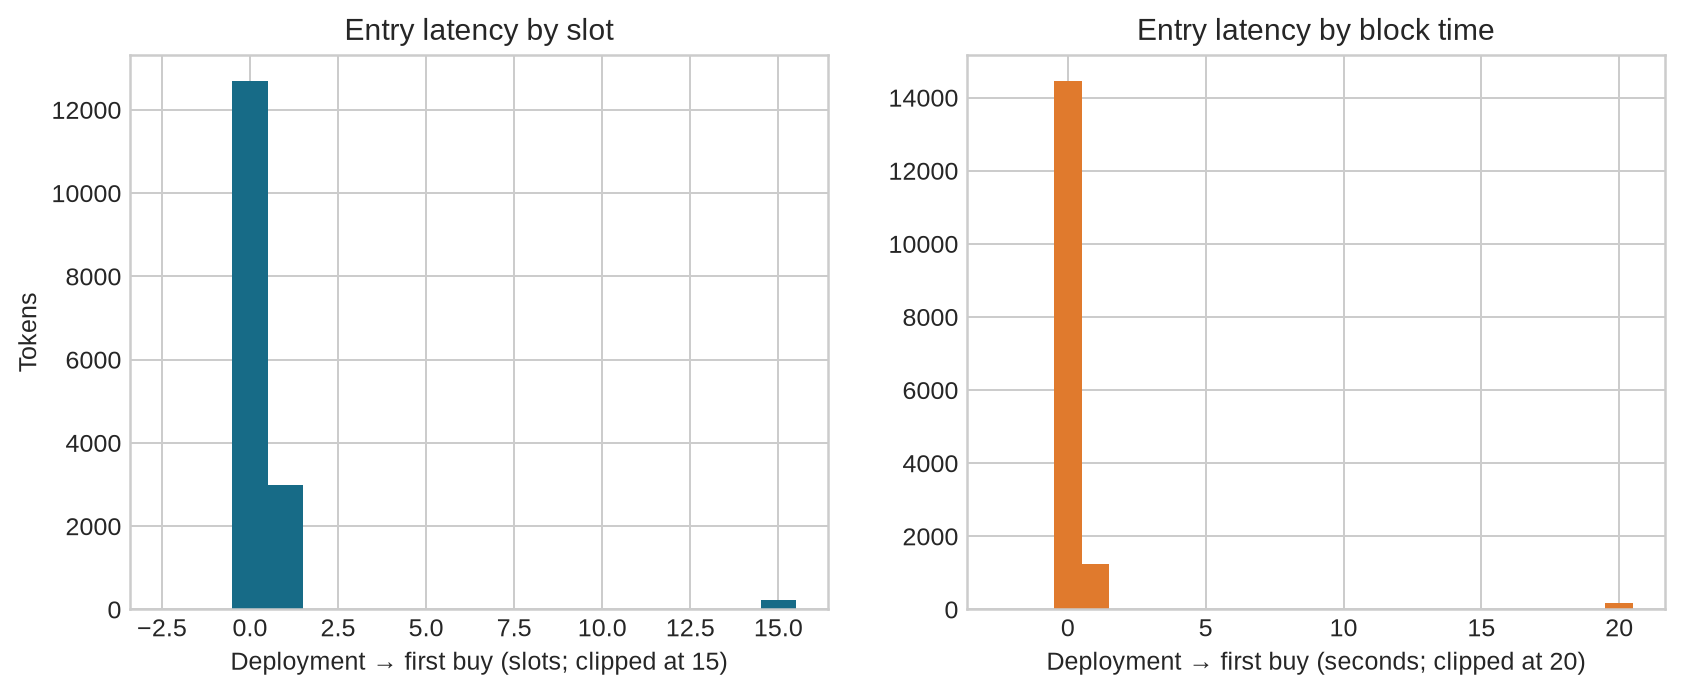

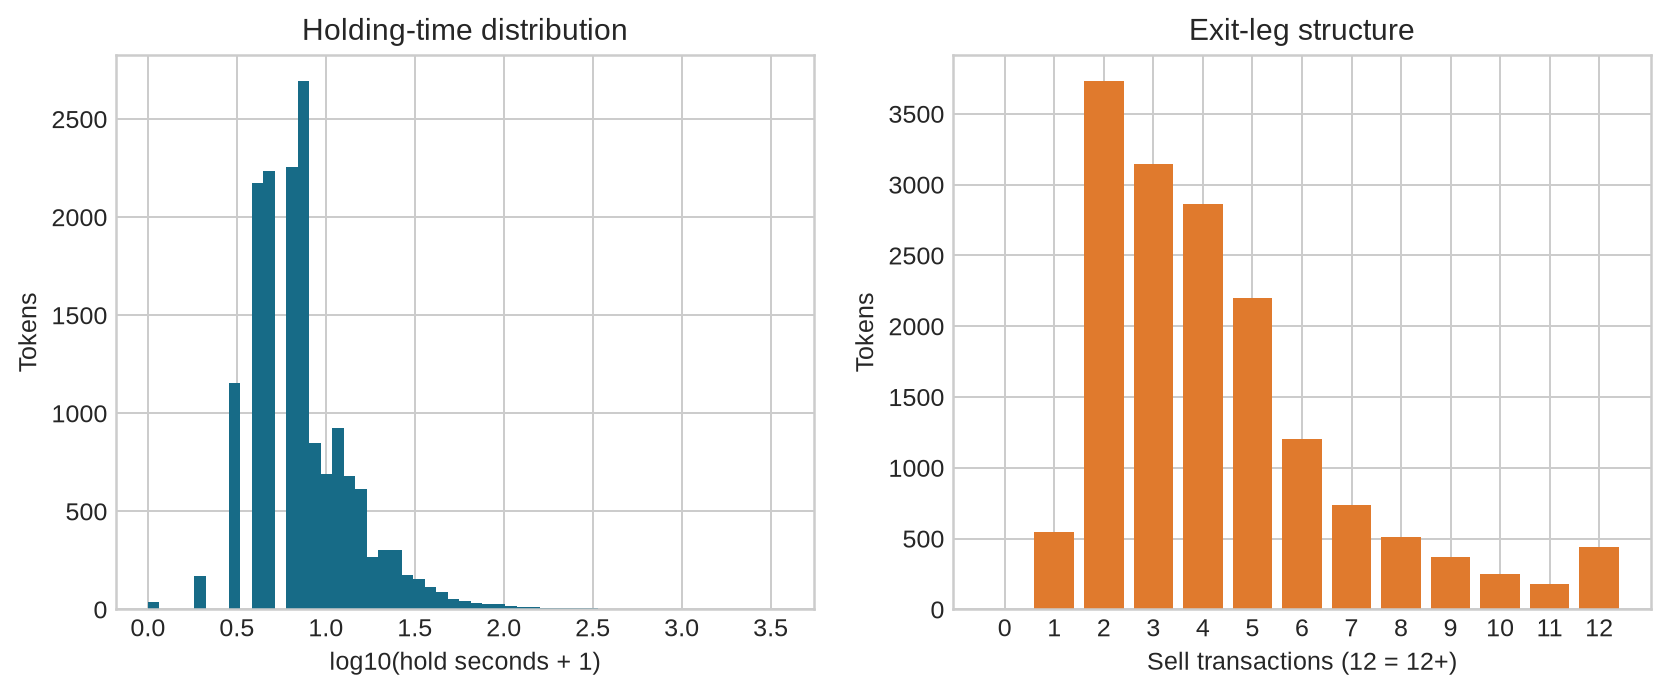

In [3]:
display_image("submission/figures/02_entry_latency.png")
display_image("submission/figures/03_holds_and_exits.png")

## 2. Leakage-safe feature reconstruction

The reproduction feature matrix is a local derived artifact, not an input to the published solution. If the exact cache is absent, the source builders stream the competition inputs and rebuild signed-message features, strict-prior deployer state, historical quality state, corrected same-second developer-sell tie groups, and live target–signer relationship state. If the cache already exists, its manifest and population counts are verified before use.

In [4]:
from solana_sniper_reverse_engineering.frozen_reproduction import build_reproduction_feature_cache

feature_path, feature_state = run_quietly(build_reproduction_feature_cache)
assert feature_state["mode"] in {"rebuilt_from_authorized_inputs", "verified_private_working_cache"}
display(
    pd.Series(
        {key: value for key, value in feature_state.items() if key != "path"},
        name="value",
    ).rename_axis("feature-state verification").to_frame()
)

,value
feature-state verification,
mode,verified_private_working_cache
rows,2145670
tokens,2145670
duplicate_tokens,0
training_population_rows,1293587
training_population_positives,6655
sampled_training_rows,650194
june_rows,852083
june_positives,4195


In [5]:
feature_dictionary = pd.read_csv("submission/tables/feature_dictionary.csv")
display(feature_dictionary[["family", "temporal_construction", "legality"]])

,family,temporal_construction,legality
0,deployment cadence,strict earlier deployment second,known before current deployment
1,timing,current deployment clock,at t_decision
2,metadata text,current signed message,message exists by t_decision
3,metadata reuse,grouped windows ending one second before,strictly earlier deployments
4,dev buy,current signed message,message exists by t_decision
5,message structure,current signed message,message exists by t_decision
6,compute budget,current signed message,message exists by t_decision
7,top-level transfers,current signed message,message exists by t_decision
8,historical activity,ASOF activity.timestamp < block_time,only strictly earlier rows
9,rolling activity,"[t-window,t) via strict ASOF states",only strictly earlier rows


## 3. Promoted target–signer relationship selector

The missing policy signal is live memory of deployment signers the target bought from previously. The frozen final recipe fits `2026-03-12 <= block_time < 2026-05-01`; April therefore enters the final weights. Full May selected the promoted family and fixed threshold `0.23211809647507783`, but May labels do not enter the fitted weights. June is reporting only.

April and May below are the frozen promotion references. June is freshly scored by a newly fitted copy of the immutable recipe.

In [6]:
from solana_sniper_reverse_engineering.frozen_reproduction import run_frozen_reproduction

fit_started = time.monotonic()
reproduction = run_quietly(run_frozen_reproduction, force_backtest=True)
reproduction_runtime_seconds = time.monotonic() - fit_started

assert reproduction["status"] == "PASS_FRESH_TRAINING_AND_JUNE_SCORING"
assert reproduction["training"]["rows_after_frozen_sampling"] == 650_194
assert reproduction["june_predictions"]["generated_by_fresh_model"] is True

relationship_validation = json.loads(
    Path("submission/tables/target_relationship_validation.json").read_text()
)
classification_rows = {
    "April promotion gate": relationship_validation["windows"]["april"]["final_plus_expanded_relationship"],
    "May promotion / threshold gate": relationship_validation["windows"]["may"]["final_plus_expanded_relationship"],
    "Fresh June reproduction": reproduction["june_metrics"],
}
display(pd.DataFrame(classification_rows).T[
    ["prevalence", "pr_auc", "precision", "recall", "f1", "predicted_entries", "true_positives"]
])

display(pd.Series({
    "frozen threshold": reproduction["june_metrics"]["threshold"],
    "fresh sampled training rows": reproduction["training"]["rows_after_frozen_sampling"],
    "fresh June rows": reproduction["june_metrics"]["rows"],
    "fresh fit + score + backtest seconds": reproduction_runtime_seconds,
}, name="reproduction summary"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,prevalence,pr_auc,precision,recall,f1,predicted_entries,true_positives
April promotion gate,0.004244,0.282063,0.325175,0.529912,0.403033,5557,1807
May promotion / threshold gate,0.005699,0.385999,0.414671,0.641324,0.503674,7852,3256
Fresh June reproduction,0.004923,0.20471,0.293239,0.425983,0.347361,6094.0,1787.0


frozen threshold                             0.232118
fresh sampled training rows             650194.000000
fresh June rows                         852083.000000
fresh fit + score + backtest seconds        24.398730
Name: reproduction summary, dtype: float64

## 4. Reverse-engineered rule and feature importance

Tree gain is descriptive, correlated importance rather than a causal decomposition. The dominant signal is whether a signer has launched repeatedly since the target last bought from it, backed by recent target-buy rates, deployment spacing, signed developer commitment, prior activity/quality, and compute-budget intent.

,rank,feature,gain_share,feature_family
0,1,deployments_since_prior_target_buy,0.585893,strict-prior target-signer relationship
1,2,seconds_since_prior_deploy,0.085917,preserved signed-message/deployer-history foun...
2,3,dev_buy_sol,0.029598,preserved signed-message/deployer-history foun...
3,4,prior_target_buy_rate_30d,0.019620,strict-prior target-signer relationship
4,5,prior_target_buy_rate_7d,0.019601,strict-prior target-signer relationship
5,6,seconds_since_activity,0.013910,preserved signed-message/deployer-history foun...
6,7,prior_deploy_count_7d,0.012037,preserved signed-message/deployer-history foun...
7,8,days_since_2026_start,0.011847,preserved signed-message/deployer-history foun...
8,9,hist_claimed_launch_fraction,0.009886,preserved signed-message/deployer-history foun...
9,10,compute_unit_price_micro_lamports,0.009475,preserved signed-message/deployer-history foun...


,family,temporal_construction,legality
0,target-signer recognition,target buy contributes only when target_buy_ti...,strictly prior public target transaction only
1,target-signer cumulative recurrence,cumulative state after strictly earlier target...,strictly prior public target transactions
2,target-signer recent recurrence,strict ASOF window ending before the current d...,strictly prior public target transactions
3,target-signer recency,current block_time minus the latest target buy...,strictly prior public target transaction
4,target-signer lifetime rates,numerator and denominator both stop before the...,strictly prior public target transactions and ...
5,target-signer recent rates,both windows end before the current deployment...,strictly prior public target transactions and ...
6,target-signer relationship age,first target buy must strictly predate the cur...,strictly prior public target transactions
7,target-signer intervening launches,counts deployments known before the current de...,strictly prior public target transactions and ...


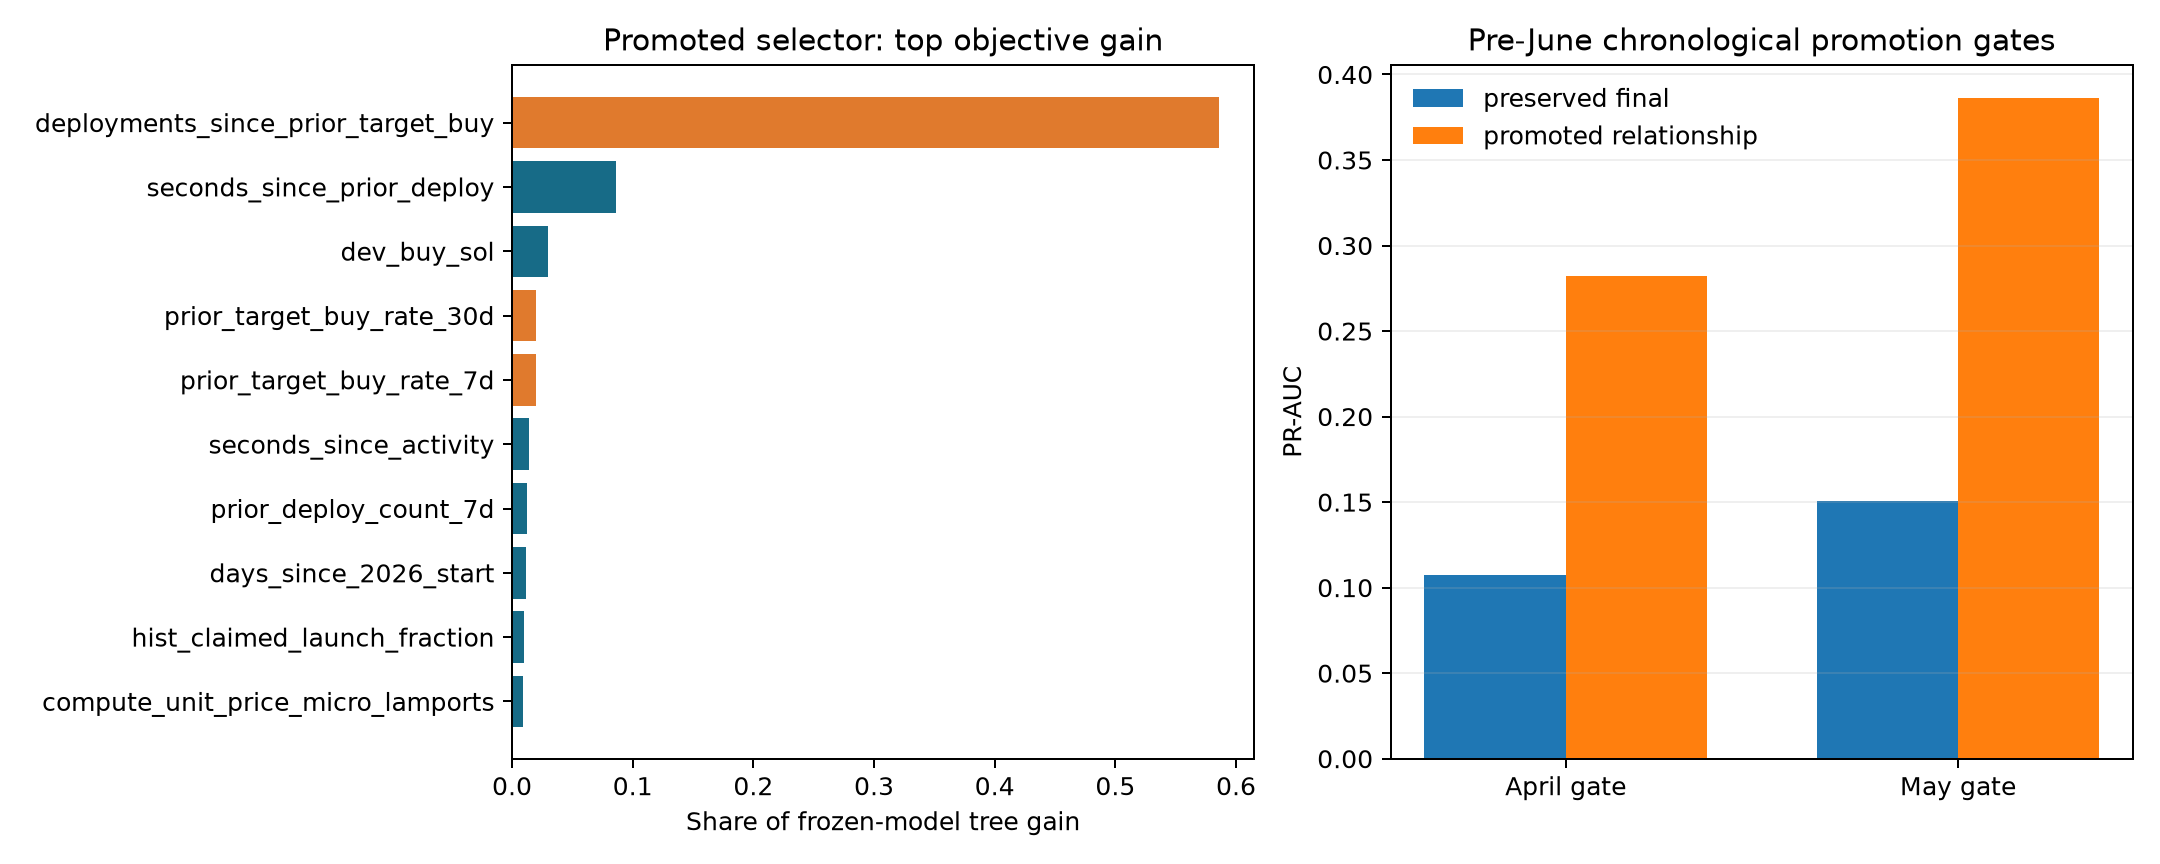

In [7]:
relationship_importance = pd.read_csv(
    "submission/tables/target_relationship_feature_importance.csv"
)
relationship_dictionary = pd.read_csv(
    "submission/tables/target_relationship_feature_dictionary.csv"
)
display(relationship_importance.head(10)[["rank", "feature", "gain_share", "feature_family"]])
display(relationship_dictionary[["family", "temporal_construction", "legality"]])
display_image("submission/figures/05_model_diagnostics.png")

## 5. Classification and economic selection are different tasks

The promoted classifier estimates whether the target wallet will buy a deployment. The separate economic selector estimates a seven-day creator-fee outcome using only labels mature before each evaluation boundary. It is retained only for the secondary exact-execution study below; its weaker target-classification PR-AUC is not presented as an alternative Part 2 result.

## 6. Primary Part 3: source-built marginal-price backtest

Fresh June selections from the promoted classifier feed the primary 0/1/2-slot marginal execution backtest. It uses the same 1.9753 SOL stake and six-second exit, subtracts the inclusive 0.09101 SOL two-leg network cost exactly once, and remains gross of proportional Pump swap fees. Immediate execution is an optimistic bound; whole-slot delays do not claim mempool visibility.

replica_entries        6094.000000
target_entries         4195.000000
overlap                1787.000000
precision_vs_target       0.293239
recall_of_target          0.425983
Name: June selection overlap, dtype: float64

,delay slots,policy,fill rate,hit rate,median ROI,p99-capped P&L SOL,max drawdown SOL
0,0,Corrected Part 2 selector,0.998195,0.667434,0.202744,8967.578449,12.680105
1,0,Target equal-stake diagnostic,1.000000,0.641001,0.156551,3536.934761,16.107711
2,1,Corrected Part 2 selector,0.998195,0.349334,-0.107145,-405.625713,332.229558
3,1,Target equal-stake diagnostic,0.999762,0.326419,-0.131348,-369.050363,338.275971
4,2,Corrected Part 2 selector,0.998195,0.346704,-0.104458,-562.159304,343.042971
5,2,Target equal-stake diagnostic,0.999762,0.340486,-0.115574,-469.462896,277.224735


quote principal paid USD          9.711513e+05
quote principal received USD      1.290788e+06
inclusive network cost USD        1.057522e+05
separate Pump cost USD            2.827424e+04
fully fee-adjusted P&L USD        1.856102e+05
fully fee-adjusted hit rate       5.725864e-01
ROI on buys + defensible costs    1.679460e-01
Name: Actual target June cash flow, dtype: float64

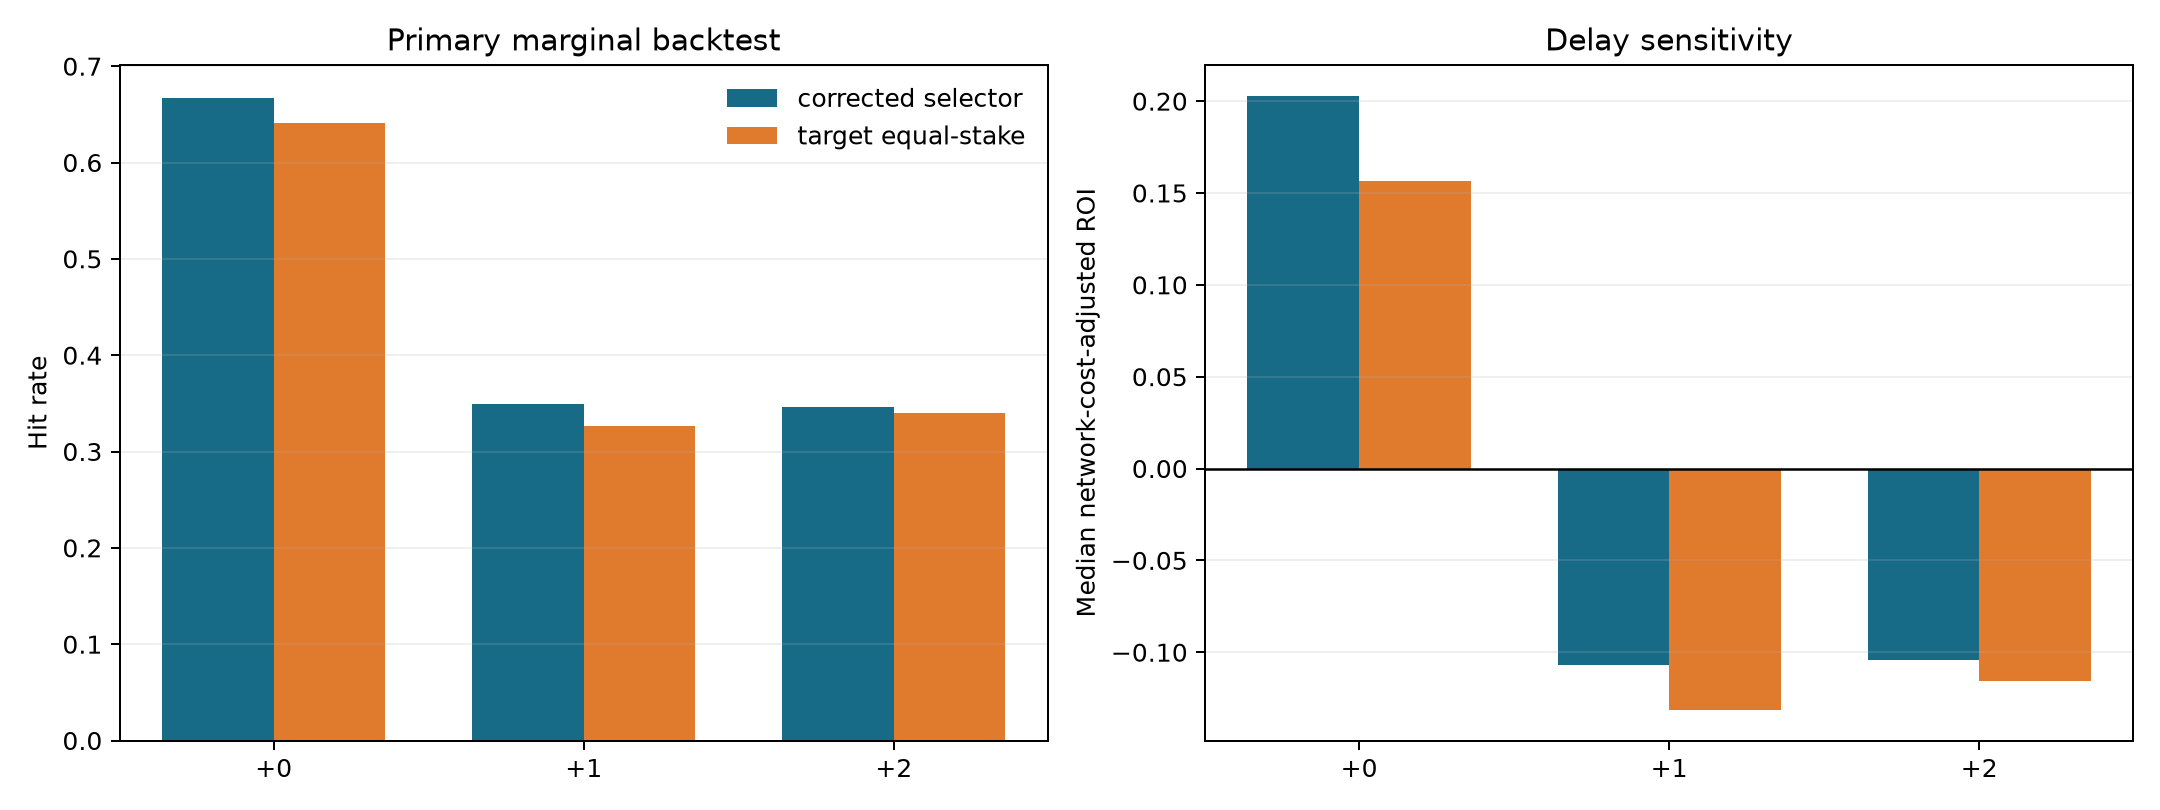

In [8]:
reproduction_backtest = reproduction["part3_reproduction"]

display(pd.Series(reproduction_backtest["selection_overlap"], name="June selection overlap"))

backtest_rows = []
for delay in (0, 1, 2):
    result = reproduction_backtest["marginal_execution"][f"delay_{delay}"]
    for label, key in (
        ("Corrected Part 2 selector", "reproduced_selector"),
        ("Target equal-stake diagnostic", "target_equal_stake"),
    ):
        row = result[key]
        backtest_rows.append({
            "delay slots": delay,
            "policy": label,
            "fill rate": row["fill_rate"],
            "hit rate": row["hit_rate"],
            "median ROI": row["median_roi"],
            "p99-capped P&L SOL": row["total_pnl_sol_roi_capped_at_p99"],
            "max drawdown SOL": row["max_drawdown_sol"],
        })

display(pd.DataFrame(backtest_rows))

actual = reproduction_backtest["actual_target_cashflow_june"]
display(pd.Series({
    "quote principal paid USD": actual["quote_principal_buy_usd"],
    "quote principal received USD": actual["quote_principal_sell_usd"],
    "inclusive network cost USD": actual["network_execution_cost_usd"],
    "separate Pump cost USD": actual["pump_separate_cost_usd"],
    "fully fee-adjusted P&L USD": actual["fully_fee_adjusted_pnl_usd"],
    "fully fee-adjusted hit rate": actual["fully_fee_adjusted_hit_rate"],
    "ROI on buys + defensible costs": actual["fully_fee_adjusted_roi_on_buy_plus_costs"],
}, name="Actual target June cash flow"))

display_image("submission/figures/06_backtest_comparison.png")

## 7. Exact Pump mechanics and bounded conclusions

The secondary integer constant-product replay refits the frozen control/quality/economic models from source, rebuilds their June memberships, and recomputes curve outcomes from the June Pump trade table. It includes our own curve impact, intervening supported events, 0.95–1.25% proportional fee assumptions, and the same inclusive network cost. Unsupported curves, migrations, delayed intent, slippage limits, and counterfactual completions remain excluded rather than guessed.

In [10]:
from solana_sniper_reverse_engineering.frozen_reproduction import (
    reproduce_frozen_exact_replay,
)

exact_reproduction = run_quietly(reproduce_frozen_exact_replay)

assert (
    exact_reproduction["status"]
    == "PASS_FRESH_STRATEGY_SELECTION_AND_EXACT_CURVE_REPLAY"
)
assert exact_reproduction["aggregate_reference_match"] is True


curve = json.loads(
    Path("submission/tables/curve_replay_results.json").read_text()
)

policy_names = {
    "Preserved control": "baseline_replica",
    "Prior quality selector": "quality_augmented_replica",
    "Equal-count two-stage": "two_stage",
    "Selective two-stage": "selective_two_stage",
}

exact_rows = []

for label, policy in policy_names.items():
    result = curve["results"]["offset_118"][policy]

    quote = result["fixed_quote"]["fee_0.0095"]
    token = result["fixed_token"]["fee_0.0095"]

    exact_rows.append({
        "strategy": label,
        "fixed-quote coverage": quote["coverage"],
        "fixed-token coverage": token["coverage"],
        "fixed-quote median ROI": quote["median_net_roi"],
        "fixed-token median ROI": token["median_net_roi"],
        "fixed-quote p99-capped P&L SOL":
            quote["p99_capped_total_pnl_sol_supported"],
        "fixed-token p99-capped P&L SOL":
            token["p99_capped_total_pnl_sol_supported"],
    })

exact_table = pd.DataFrame(exact_rows)

for column in (
    "fixed-quote coverage",
    "fixed-token coverage",
    "fixed-quote median ROI",
    "fixed-token median ROI",
):
    exact_table[column] = exact_table[column].map("{:.2%}".format)

display(exact_table)


selective_125 = curve["results"]["offset_118"]["selective_two_stage"]

display(pd.Series({
    "1.25% fixed-quote p99-capped P&L SOL":
        selective_125["fixed_quote"]["fee_0.0125"][
            "p99_capped_total_pnl_sol_supported"
        ],
    "1.25% fixed-token p99-capped P&L SOL":
        selective_125["fixed_token"]["fee_0.0125"][
            "p99_capped_total_pnl_sol_supported"
        ],
    "fresh exact replay seconds":
        exact_reproduction["elapsed_seconds"],
}, name="Selective strategy upper-fee bound"))

,strategy,fixed-quote coverage,fixed-token coverage,fixed-quote median ROI,fixed-token median ROI,fixed-quote p99-capped P&L SOL,fixed-token p99-capped P&L SOL
0,Preserved control,48.54%,50.17%,-9.91%,-7.77%,-141.005995,-12.316796
1,Prior quality selector,43.43%,44.89%,-10.41%,-8.50%,-212.397397,-43.389512
2,Equal-count two-stage,45.28%,46.59%,-9.45%,-7.49%,-174.075183,16.951924
3,Selective two-stage,46.86%,47.93%,-8.46%,-7.06%,-8.963816,38.197889


1.25% fixed-quote p99-capped P&L SOL    -16.979118
1.25% fixed-token p99-capped P&L SOL     29.856128
fresh exact replay seconds              136.609801
Name: Selective strategy upper-fee bound, dtype: float64

## Conclusion

The dominant reverse-engineered policy signal is strict online memory of deployment signers the target wallet bought from previously. The signal is strong across both pre-June chronological gates: PR-AUC reaches **0.282063 in April** and **0.385999 in May**, with the May promotion gate achieving **41.47% precision** and **64.13% recall**. The frozen model then scores **0.2047103771 PR-AUC in June**, with **29.32% precision**, **42.60% recall**, and **1,787 true positives across 6,094 selections**. June is materially weaker than April and May, but it is reporting-only: no June labels were used for training, threshold selection, or redesign.

The recovered policy is therefore not a static signer whitelist. It is a live, strict-prior relationship state that updates only after a target buy has actually occurred. The strongest feature, `deployments_since_prior_target_buy`, accounts for **58.59% of model gain**, with recent target-buy rates and ordinary deployer-history features providing additional context.

Execution is the main economic constraint. In the primary marginal-price backtest, immediate execution for the corrected selector has a **66.74% hit rate** and **+20.27% median ROI**, but delaying entry by one slot reduces the hit rate to **34.93%** and the median ROI to **-10.71%**. The target wallet's actual June activity remains profitable at **+$185,610.17 fully fee-adjusted P&L** and **16.79% ROI**, but its variable sizing and multi-exit behavior are not directly comparable to the equal-stake replica.

The stricter exact Pump replay reinforces the latency constraint rather than overturning it. At the observed +118 transaction-position diagnostic, the selective two-stage strategy has **46.86-47.93% supported coverage** and median fully modeled ROI of **-8.46% to -7.06%** under the two observed buy-intent bounds. Its p99-capped P&L ranges from **-9.0 to +38.2 SOL at 0.95% fees**, and from **-17.0 to +29.9 SOL at 1.25% fees**.

The main result is therefore a reproducible reconstruction of a measurable target-selection policy, not a claim of guaranteed trading profitability. The classification signal generalizes into June, but the economic edge is highly sensitive to execution latency, exact transaction intent, and curve mechanics.